# German day-ahead electricity prices: data quality, EDA and first models

**Question:** At 11:00 Europe/Berlin on D-1, how accurately can we predict each hourly
wholesale price for delivery day D? The target is `price_eur_mwh` for Germany-Luxembourg.
The output has 24 hourly prices on ordinary days, 23/25 on clock-change days.
The post-October-2025 target is the provider's hourly price representation of a
15-minute market, not a forecast of every quarter-hour product.

This notebook loads local files, explains every column, audits data quality, explores
development-period relationships, and evaluates two baselines plus two LightGBM models.
It makes **no network calls** and does not alter raw data. Run all cells in order using
the project's `.venv` Python interpreter. Runtime depends on your computer.

**Frozen evaluation:** 2025-09-25 through 2026-09-24 inclusive, local delivery dates.
Parameters are fixed before this first evaluation. Do not tune on the resulting test scores.
Full-history summaries were viewed earlier, so this is a retrospective holdout, not an
untouched prospective trial. A future live evaluation remains necessary.

In [1]:
import hashlib
import importlib.metadata
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
sys.path.insert(0, str(ROOT / 'src'))
from lightgbm import LGBMRegressor

from depower.backtest import SeasonalNaive, rolling_backtest
from depower.features import TARGET, TZ, build_features

OUT = ROOT / 'data/processed/eda'
OUT.mkdir(parents=True, exist_ok=True)
TEST_START, TEST_END = '2025-09-25', '2026-09-24'
TEST_BEGIN = pd.Timestamp(TEST_START, tz=TZ).tz_convert('UTC')
TEST_STOP = (pd.Timestamp(TEST_END, tz=TZ) + pd.DateOffset(days=1)).tz_convert('UTC')
expected_test = pd.date_range(TEST_BEGIN, TEST_STOP, freq='h', inclusive='left')
SEED = 42
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.2})

def finish(fig, name):
    fig.text(0.01, 0.005, 'Sources: Bundesnetzagentur | SMARD.de; weather: Open-Meteo', fontsize=8)
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    fig.savefig(OUT / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print('Project:', ROOT)
print('Python:', sys.executable)
print('Test delivery days:', TEST_START, 'through', TEST_END, '| expected hours:', len(expected_test))

Project: C:\Users\rosha\OneDrive\Documents\de-power-price-forecast
Python: C:\Users\rosha\OneDrive\Documents\de-power-price-forecast\.venv\Scripts\python.exe
Test delivery days: 2025-09-25 through 2026-09-24 | expected hours: 8760


## 1. Load the data and preserve its identity

While both market snapshots exist, use `smard_sample.parquet` (the later download already
used in this notebook). After you replace the older `smard.parquet` with that file, the
fallback below uses `smard.parquet`. Never concatenate these overlapping snapshots.
SHA-256 hashes record exactly which bytes produced the results.

In [2]:
raw = ROOT / 'data/raw'
market_path = raw / 'smard_sample.parquet'
if not market_path.exists():
    market_path = raw / 'smard.parquet'
paths = {'market': market_path, 'weather_archive': raw / 'weather_archive.parquet',
         'weather_forecast': raw / 'weather_forecast.parquet'}
datasets = {name: pd.read_parquet(path) for name, path in paths.items()}
market, archive, forecast = (datasets[k] for k in ['market', 'weather_archive', 'weather_forecast'])
forecast_meta = json.loads((raw / 'weather_forecast.metadata.json').read_text(encoding='utf-8'))
manifest = {name: {'file': str(path.relative_to(ROOT)),
                   'sha256': hashlib.sha256(path.read_bytes()).hexdigest()}
            for name, path in paths.items()}
display(pd.DataFrame(manifest).T)
display(market.head())
print('Forecast source:', forecast_meta['endpoint'])
print('Weather model:', forecast_meta['model'], '| lead time:', forecast_meta['lead_hours'], 'hours')
assert forecast_meta['source'] == 'forecast' and forecast_meta['lead_hours'] == 48
assert forecast_meta['endpoint'] == 'https://previous-runs-api.open-meteo.com/v1/forecast'

,file,sha256
market,data\raw\smard_sample.parquet,3b43a706a14dbca277f3f9d01d1d66a1fcf0fde5af5f66...
weather_archive,data\raw\weather_archive.parquet,4a87e5e029a403a9351c612a2f9025bb3e5f1f166fbe90...
weather_forecast,data\raw\weather_forecast.parquet,22c8ed65cec69e0aa9d1e58f3818dc1e05c3e310f1e958...


,price_eur_mwh,load_mwh,residual_load_mwh,solar_mwh,wind_onshore_mwh,wind_offshore_mwh
ts,,,,,,
2019-01-01 00:00:00+00:00,10.07,41631.25,16465.75,0.0,22297.25,2868.25
2019-01-01 01:00:00+00:00,-4.08,40085.00,14456.25,0.0,23168.50,2460.25
2019-01-01 02:00:00+00:00,-9.91,39269.75,12101.50,0.0,24471.75,2696.50
2019-01-01 03:00:00+00:00,-7.41,39032.75,10134.25,0.0,26320.50,2578.00
2019-01-01 04:00:00+00:00,-12.55,38570.50,8295.25,0.0,27898.00,2377.25


Forecast source: https://previous-runs-api.open-meteo.com/v1/forecast
Weather model: ecmwf_ifs025 | lead time: 48 hours


## 2. Units, columns and a worked negative-price example

One row is one UTC hour. `ts`/`time` is the delivery/valid timestamp, not the publication
timestamp. Calendar features use Europe/Berlin. Prices cover the DE-LU bidding zone;
the physical market series cover DE.

**MWh is energy:** 1 MWh = 1,000 kWh. 50,000 MWh in a one-hour interval corresponds
to 50,000 MW average power. **EUR/MWh is a price:** EUR 100/MWh = EUR 0.10/kWh
before retail charges. Actual generation is output, not installed generating capacity.

Negative wholesale prices can occur when offered supply is abundant relative to demand
and some generators accept negative bids because stopping/restarting is costly or other
operating incentives apply. The physical system still balances. A buyer purchasing 10 MWh
at -80.01 EUR/MWh has an energy-only payment of -800.10 EUR: it receives EUR 800.10.
The seller pays that amount under this simple spot transaction. Contracts, fees and retail
tariffs can change what individual participants ultimately pay.

Keep negative prices and spikes: they are part of the forecasting problem.
[SMARD explanation](https://www.smard.de/page/en/topic-article/5892/15618/negative-electricity-prices).

In [3]:
example_time = pd.Timestamp('2024-06-15 12:00', tz='UTC')
example = market.loc[example_time]
definitions = {
    TARGET: ('EUR/MWh', 'Wholesale day-ahead price; the prediction target.'),
    'load_mwh': ('MWh', 'Actual grid load; system consumption with provider accounting boundaries.'),
    'residual_load_mwh': ('MWh', 'Grid load minus solar, onshore wind and offshore wind.'),
    'solar_mwh': ('MWh', 'Electricity produced by photovoltaic installations during the interval.'),
    'wind_onshore_mwh': ('MWh', 'Electricity produced by wind turbines on land.'),
    'wind_offshore_mwh': ('MWh', 'Electricity produced by offshore wind turbines.'),
}
market_dictionary = pd.DataFrame([
    {'column': c, 'unit': unit, 'meaning': meaning, 'example_value': example[c]}
    for c, (unit, meaning) in definitions.items()
]).set_index('column')
display(market_dictionary)
print('Example UTC:', example_time, '| local:', example_time.tz_convert(TZ))
computed_residual = (example.load_mwh - example.solar_mwh
                     - example.wind_onshore_mwh - example.wind_offshore_mwh)
print(f'Residual = {example.load_mwh:,.2f} - {example.solar_mwh:,.2f}'
      f' - {example.wind_onshore_mwh:,.2f} - {example.wind_offshore_mwh:,.2f}'
      f' = {computed_residual:,.2f} MWh')
print(f'Energy-only payment for buying 10 MWh: EUR {10 * example[TARGET]:,.2f}')
market_dictionary.to_csv(OUT / 'market_dictionary.csv')

,unit,meaning,example_value
column,,,
price_eur_mwh,EUR/MWh,Wholesale day-ahead price; the prediction target.,-80.01
load_mwh,MWh,Actual grid load; system consumption with prov...,46043.50
residual_load_mwh,MWh,"Grid load minus solar, onshore wind and offsho...",478.75
solar_mwh,MWh,Electricity produced by photovoltaic installat...,31521.25
wind_onshore_mwh,MWh,Electricity produced by wind turbines on land.,12282.25
wind_offshore_mwh,MWh,Electricity produced by offshore wind turbines.,1761.25


Example UTC: 2024-06-15 12:00:00+00:00 | local: 2024-06-15 14:00:00+02:00
Residual = 46,043.50 - 31,521.25 - 12,282.25 - 1,761.25 = 478.75 MWh
Energy-only payment for buying 10 MWh: EUR -800.10


Each weather name is `location__variable`: five locations times four variables = 20 columns.
`temperature_2m` is degrees Celsius; `wind_speed_100m` is km/h (divide by 3.6 for m/s);
`shortwave_radiation` is W/m2; `cloud_cover` is percent. The weather points are regional
proxies, not region-wide averages. Radiation is the API's preceding-hour mean, retained
at the provider timestamp here; it is not claimed to represent the exact same physical
interval as the market energy measurement.

Archive weather is retrospective model-based information, not perfect ground truth.
It is used only for descriptive analysis below. Forecast weather is a separate archive
of model predictions at a 48-hour lead. No archive values enter either price model.
[Open-Meteo definitions](https://open-meteo.com/en/docs/historical-weather-api).

In [4]:
weather_definitions = {
    'temperature_2m': ('degC', 'Air temperature 2 m above ground; may affect heating/cooling demand.'),
    'wind_speed_100m': ('km/h', 'Wind 100 m above ground; proxy for wind-turbine conditions.'),
    'shortwave_radiation': ('W/m2', 'Incoming horizontal solar radiation; proxy for available sunlight.'),
    'cloud_cover': ('%', 'Sky cloud fraction; 100 means fully cloud-covered, not zero radiation.'),
}
weather_dictionary = []
for column in archive:
    location, variable = column.split('__')
    unit, meaning = weather_definitions[variable]
    weather_dictionary.append({'column': column, 'location': location, 'unit': unit,
                               'meaning': meaning, 'archive_example': archive.loc[example_time, column],
                               'forecast_example_48h': forecast.loc[example_time, column]})
weather_dictionary = pd.DataFrame(weather_dictionary).set_index('column')
display(weather_dictionary)
weather_dictionary.to_csv(OUT / 'weather_dictionary.csv')

,location,unit,meaning,archive_example,forecast_example_48h
column,,,,,
north_sea_coast__temperature_2m,north_sea_coast,degC,Air temperature 2 m above ground; may affect h...,15.5,17.0
north_sea_coast__wind_speed_100m,north_sea_coast,km/h,Wind 100 m above ground; proxy for wind-turbin...,45.9,36.5
north_sea_coast__shortwave_radiation,north_sea_coast,W/m2,Incoming horizontal solar radiation; proxy for...,586.0,677.0
north_sea_coast__cloud_cover,north_sea_coast,%,Sky cloud fraction; 100 means fully cloud-cove...,45.0,23.0
brandenburg__temperature_2m,brandenburg,degC,Air temperature 2 m above ground; may affect h...,21.4,19.3
brandenburg__wind_speed_100m,brandenburg,km/h,Wind 100 m above ground; proxy for wind-turbin...,32.1,28.4
brandenburg__shortwave_radiation,brandenburg,W/m2,Incoming horizontal solar radiation; proxy for...,823.0,418.0
brandenburg__cloud_cover,brandenburg,%,Sky cloud fraction; 100 means fully cloud-cove...,46.0,0.0
ruhr__temperature_2m,ruhr,degC,Air temperature 2 m above ground; may affect h...,17.6,17.9


## 3. Data-quality audit (all downloaded rows)

Separate a missing timestamp from a present timestamp with a missing value. Missing
recent generation is retained as missing, never converted to zero. UTC has no DST gap;
local delivery-day lengths must be compared to the calendar's expected 23/24/25 hours.
The first/last partial day can also contain fewer than 24 observations.

In [5]:
quality_rows, missing_rows = [], []
for name, df in datasets.items():
    assert isinstance(df.index, pd.DatetimeIndex) and str(df.index.tz) == 'UTC'
    expected = pd.date_range(df.index.min(), df.index.max(), freq='h')
    quality_rows.append({'dataset': name, 'rows': len(df), 'columns': df.shape[1],
                         'start_utc': df.index.min(), 'end_utc': df.index.max(),
                         'duplicates': int(df.index.duplicated().sum()),
                         'sorted': df.index.is_monotonic_increasing,
                         'missing_timestamps': len(expected.difference(df.index)),
                         'non_finite_non_null': int((~np.isfinite(df) & df.notna()).sum().sum())})
    for column in df:
        mask = df[column].isna()
        missing_rows.append({'dataset': name, 'column': column, 'missing': int(mask.sum()),
                             'missing_pct': float(mask.mean() * 100),
                             'first_missing': df.index[mask].min(), 'last_missing': df.index[mask].max()})
quality = pd.DataFrame(quality_rows).set_index('dataset')
missing_values = pd.DataFrame(missing_rows)
display(quality)
display(missing_values.loc[missing_values.missing > 0])
assert (quality.duplicates == 0).all() and quality['sorted'].all()
assert (quality.missing_timestamps == 0).all() and (quality.non_finite_non_null == 0).all()
quality.to_csv(OUT / 'data_quality.csv')
missing_values.to_csv(OUT / 'missing_values.csv', index=False)
display(market.describe(percentiles=[.01, .5, .99]).T)

,rows,columns,start_utc,end_utc,duplicates,sorted,missing_timestamps,non_finite_non_null
dataset,,,,,,,,
market,67822,6,2019-01-01 00:00:00+00:00,2026-09-26 21:00:00+00:00,0,True,0,0
weather_archive,67800,20,2019-01-01 00:00:00+00:00,2026-09-25 23:00:00+00:00,0,True,0,0
weather_forecast,21792,20,2024-04-01 00:00:00+00:00,2026-09-25 23:00:00+00:00,0,True,0,0


,dataset,column,missing,missing_pct,first_missing,last_missing
1,market,load_mwh,28,0.041285,2026-09-25 18:00:00+00:00,2026-09-26 21:00:00+00:00
2,market,residual_load_mwh,28,0.041285,2026-09-25 18:00:00+00:00,2026-09-26 21:00:00+00:00
3,market,solar_mwh,28,0.041285,2026-09-25 18:00:00+00:00,2026-09-26 21:00:00+00:00
4,market,wind_onshore_mwh,28,0.041285,2026-09-25 18:00:00+00:00,2026-09-26 21:00:00+00:00
5,market,wind_offshore_mwh,27,0.039810,2026-09-25 19:00:00+00:00,2026-09-26 21:00:00+00:00
29,weather_forecast,north_sea_coast__cloud_cover,129,0.591960,2026-04-17 15:00:00+00:00,2026-04-22 23:00:00+00:00
33,weather_forecast,brandenburg__cloud_cover,129,0.591960,2026-04-17 15:00:00+00:00,2026-04-22 23:00:00+00:00
37,weather_forecast,ruhr__cloud_cover,129,0.591960,2026-04-17 15:00:00+00:00,2026-04-22 23:00:00+00:00
41,weather_forecast,bavaria__cloud_cover,129,0.591960,2026-04-17 15:00:00+00:00,2026-04-22 23:00:00+00:00
45,weather_forecast,baden_wuerttemberg__cloud_cover,129,0.591960,2026-04-17 15:00:00+00:00,2026-04-22 23:00:00+00:00


,count,mean,std,min,1%,50%,99%,max
price_eur_mwh,67822.0,95.917205,91.561801,-500.00,-11.1000,78.675,472.4697,936.28
load_mwh,67794.0,54570.284995,9629.554123,30902.75,36018.1975,54447.570,74490.8500,81319.50
residual_load_mwh,67794.0,33025.534944,14097.555440,-15561.59,-1285.5475,33885.640,63177.8200,74638.75
solar_mwh,67794.0,6735.517077,10555.029630,0.00,0.0000,238.500,42128.5195,58055.53
wind_onshore_mwh,67794.0,11923.932304,9410.937843,46.50,655.3709,9246.000,39226.4700,48499.50
wind_offshore_mwh,67795.0,2885.281240,1963.406757,0.00,34.2500,2658.500,6984.6924,8448.34


In [6]:
local_index = market.index.tz_convert(TZ)
day_counts = market.groupby(local_index.normalize()).size().rename('observed_hours').to_frame()
day_counts['expected_hours'] = [len(pd.date_range(day, day + pd.DateOffset(days=1),
                                                freq='h', inclusive='left')) for day in day_counts.index]
day_counts['complete'] = day_counts.observed_hours == day_counts.expected_hours
display(day_counts.loc[(day_counts.expected_hours != 24) | ~day_counts.complete])
day_counts.to_csv(OUT / 'delivery_day_coverage.csv')

physical = ['load_mwh', 'solar_mwh', 'wind_onshore_mwh', 'wind_offshore_mwh']
print('Negative physical energy values:', (market[physical] < 0).sum().to_dict())
print('Negative residual-load hours (valid):', int((market.residual_load_mwh < 0).sum()))
for df_name, df in [('archive', archive), ('forecast', forecast)]:
    invalid = {}
    for c in df:
        if c.endswith('cloud_cover'):
            invalid[c] = int(((df[c] < 0) | (df[c] > 100)).sum())
        elif c.endswith(('wind_speed_100m', 'shortwave_radiation')):
            invalid[c] = int((df[c] < 0).sum())
    print(df_name, 'weather range violations:', sum(invalid.values()))

,observed_hours,expected_hours,complete
ts,,,
2019-01-01 00:00:00+01:00,23,24,False
2019-03-31 00:00:00+01:00,23,23,True
2019-10-27 00:00:00+02:00,25,25,True
2020-03-29 00:00:00+01:00,23,23,True
2020-10-25 00:00:00+02:00,25,25,True
2021-03-28 00:00:00+01:00,23,23,True
2021-10-31 00:00:00+02:00,25,25,True
2022-03-27 00:00:00+01:00,23,23,True
2022-10-30 00:00:00+02:00,25,25,True


Negative physical energy values: {'load_mwh': 0, 'solar_mwh': 0, 'wind_onshore_mwh': 0, 'wind_offshore_mwh': 0}
Negative residual-load hours (valid): 872
archive weather range violations: 0
forecast weather range violations: 0


In [7]:
residual_recomputed = (market.load_mwh - market.solar_mwh
                       - market.wind_onshore_mwh - market.wind_offshore_mwh)
residual_error = (market.residual_load_mwh - residual_recomputed).rename('residual_difference_mwh')
residual_flags = market.loc[residual_error.abs() > .1].copy()
residual_flags['residual_difference_mwh'] = residual_error
display(residual_error.describe())
display(residual_flags.loc[residual_flags.residual_difference_mwh.abs().nlargest(10).index])
print('Differences greater than 0.1 MWh:', len(residual_flags))
residual_flags.to_csv(OUT / 'residual_load_flags.csv')

snapshot_differences = []
if (raw / 'smard.parquet').exists() and (raw / 'smard_sample.parquet').exists():
    older = pd.read_parquet(raw / 'smard.parquet')
    newer = pd.read_parquet(raw / 'smard_sample.parquet')
    common = older.index.intersection(newer.index)
    for c in market:
        a, b = older.loc[common, c], newer.loc[common, c]
        different = a.ne(b) & ~(a.isna() & b.isna())
        snapshot_differences.append({'column': c, 'different_cells': int(different.sum()),
                                     'max_abs_difference_when_both_present': (a-b).abs().max()})
    display(pd.DataFrame(snapshot_differences))
else:
    print('Only one market snapshot remains; no overlapping files were combined.')

count    67794.000000
mean        -0.003573
std          0.414381
min       -103.410000
25%          0.000000
50%          0.000000
75%          0.000000
max         13.880000
Name: residual_difference_mwh, dtype: float64

,price_eur_mwh,load_mwh,residual_load_mwh,solar_mwh,wind_onshore_mwh,wind_offshore_mwh,residual_difference_mwh
ts,,,,,,,
2026-09-23 04:00:00+00:00,300.00,54672.14,52196.17,1.52,1597.94,773.10,-103.41
2021-01-06 16:00:00+00:00,61.84,67835.00,60243.25,1.00,4394.75,3179.50,-16.50
2021-01-06 14:00:00+00:00,57.53,64927.00,57386.38,353.50,4191.50,3009.50,13.88
2021-01-06 07:00:00+00:00,53.41,63076.25,52245.50,98.75,5993.25,4747.75,9.00
2021-01-05 12:00:00+00:00,63.82,70739.00,54252.00,1128.25,9128.25,6226.50,-4.00
2021-01-05 17:00:00+00:00,61.61,71259.75,55054.25,1.00,10132.75,6067.75,-4.00
2021-01-04 20:00:00+00:00,45.64,62577.00,47027.00,1.00,9604.75,5940.75,-3.50
2021-01-04 10:00:00+00:00,60.00,70311.25,53185.75,1049.00,10290.00,5783.25,-3.25
2021-01-04 14:00:00+00:00,59.46,69013.00,52313.75,214.50,10721.00,5760.50,-3.25


Differences greater than 0.1 MWh: 71


,column,different_cells,max_abs_difference_when_both_present
0,price_eur_mwh,0,0.0
1,load_mwh,20,4.0
2,residual_load_mwh,20,4.0
3,solar_mwh,0,0.0
4,wind_onshore_mwh,0,0.0
5,wind_offshore_mwh,1,0.0


**Quality decisions:** retain negative prices, negative residual load and all price spikes;
retain missing recent physical values; keep published residual load and export discrepancies
for investigation; never fill gaps using future values. Use timestamp joins rather than row
position. Source revisions and missing publication timestamps limit an exact historical
information reconstruction. Data completeness alone does not prove absence of leakage.

## 4. Explore development data before the test period

All relationship and distribution plots in this section stop before the frozen test period.
The same-hour physical variables and archive weather help explain the market, but they
are **not** available as same-hour actuals for a day-ahead forecast. Correlation is not
causation. Pooling years can hide changes in fuel prices, installed renewable capacity,
outages and cross-border trading, none of which is fully represented in these six columns.

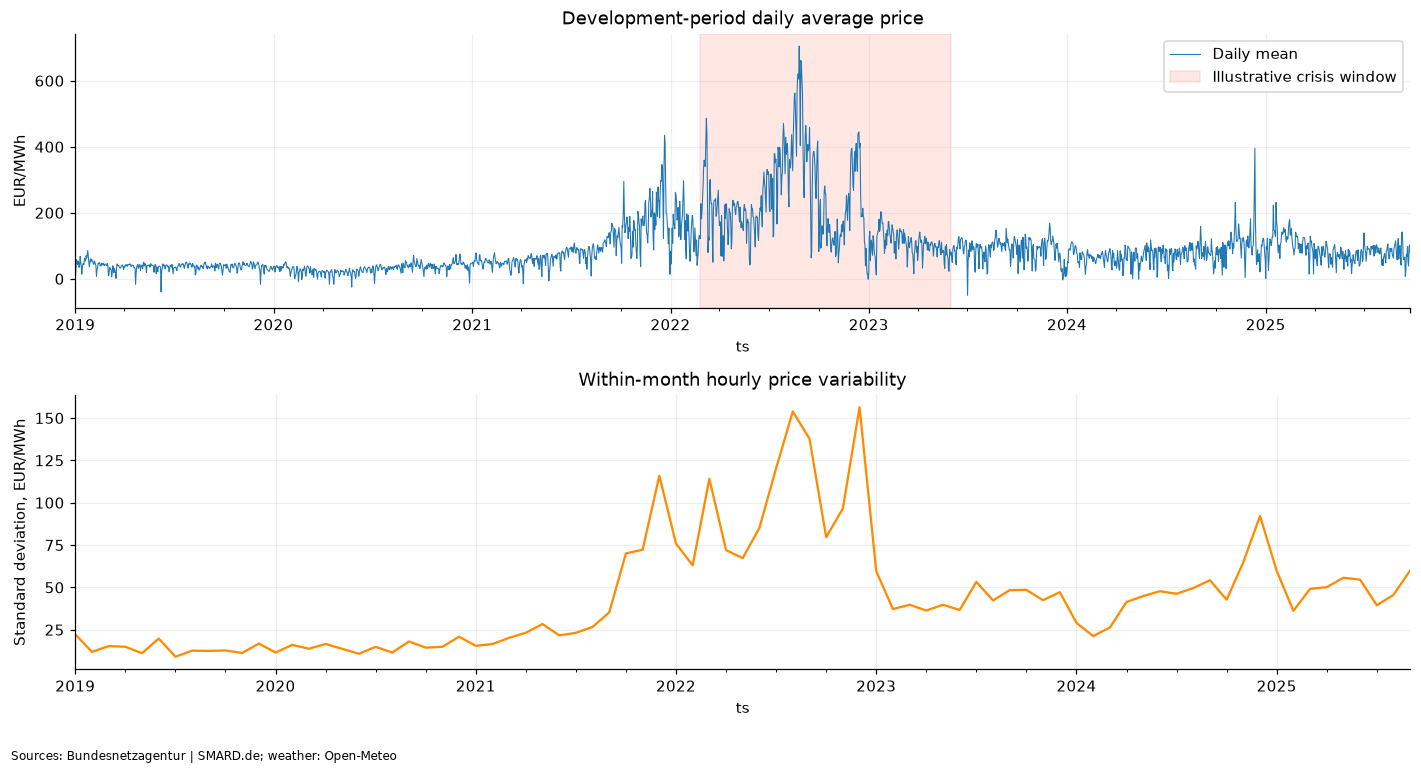

In [8]:
eda = market.loc[market.index < TEST_BEGIN].copy()
eda_local = eda.tz_convert(TZ)
price = eda[TARGET]
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
price.resample('D').mean().plot(ax=axes[0], linewidth=.7, label='Daily mean')
axes[0].set(title='Development-period daily average price', ylabel='EUR/MWh')
axes[0].axvspan(pd.Timestamp('2022-02-24', tz='UTC'), pd.Timestamp('2023-06-01', tz='UTC'),
               color='tomato', alpha=.15, label='Illustrative crisis window')
axes[0].legend()
price.resample('MS').std().plot(ax=axes[1], color='darkorange')
axes[1].set(title='Within-month hourly price variability', ylabel='Standard deviation, EUR/MWh')
finish(fig, '01_price_history')

Central plot omits 1298 out-of-range hours; original data unchanged.


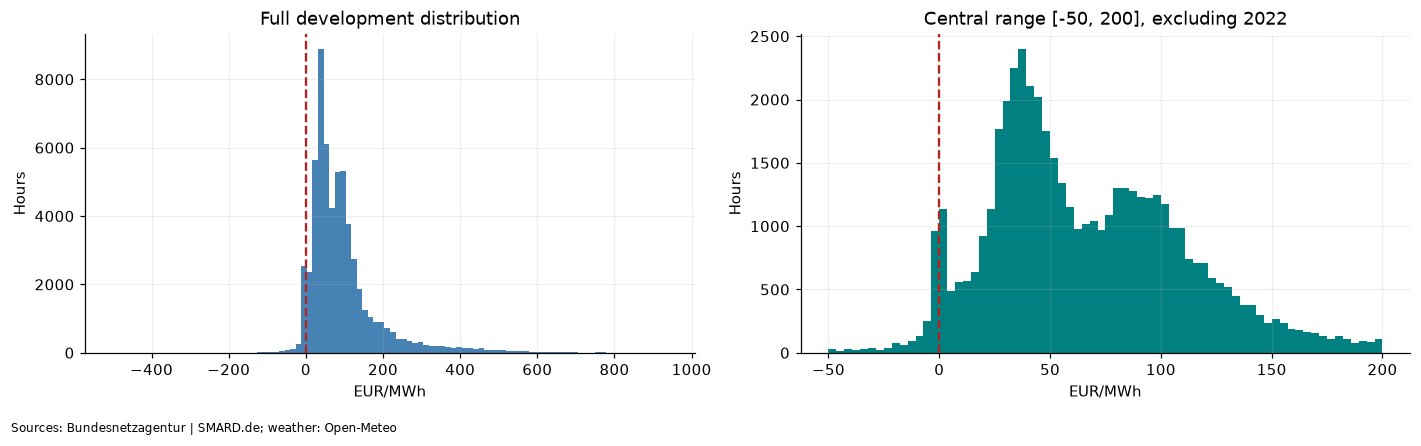

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(price, bins=100, color='steelblue')
axes[0].set(title='Full development distribution', xlabel='EUR/MWh', ylabel='Hours')
without_2022 = price.loc[price.index.tz_convert(TZ).year != 2022]
central = without_2022.loc[without_2022.between(-50, 200)]
axes[1].hist(central, bins=70, color='teal')
axes[1].set(title='Central range [-50, 200], excluding 2022', xlabel='EUR/MWh', ylabel='Hours')
for ax in axes:
    ax.axvline(0, color='firebrick', linestyle='--')
print('Central plot omits', len(without_2022)-len(central), 'out-of-range hours; original data unchanged.')
finish(fig, '02_price_distribution')

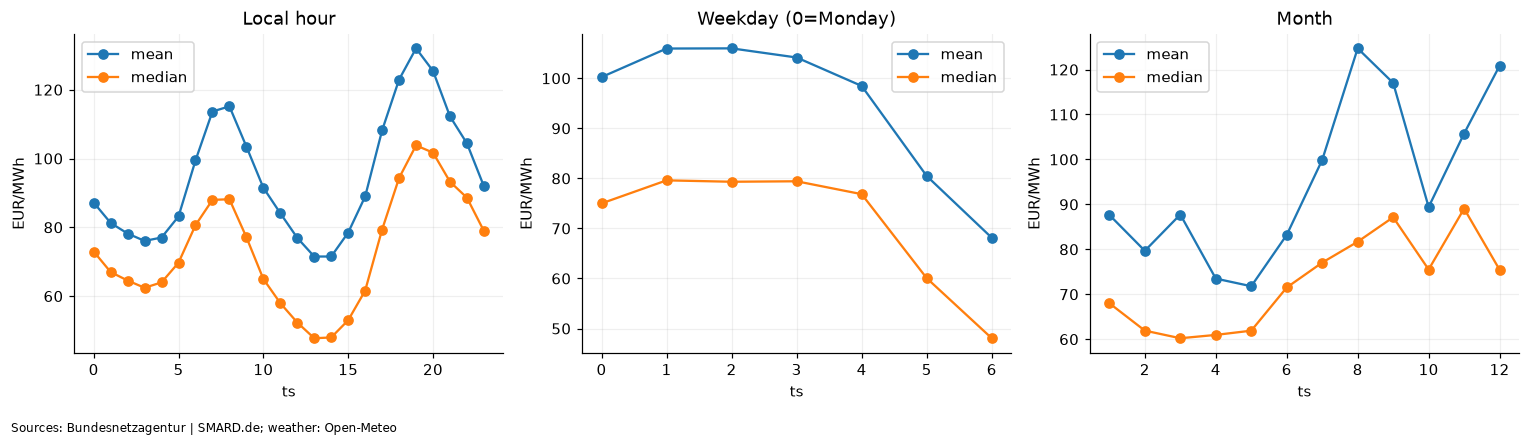

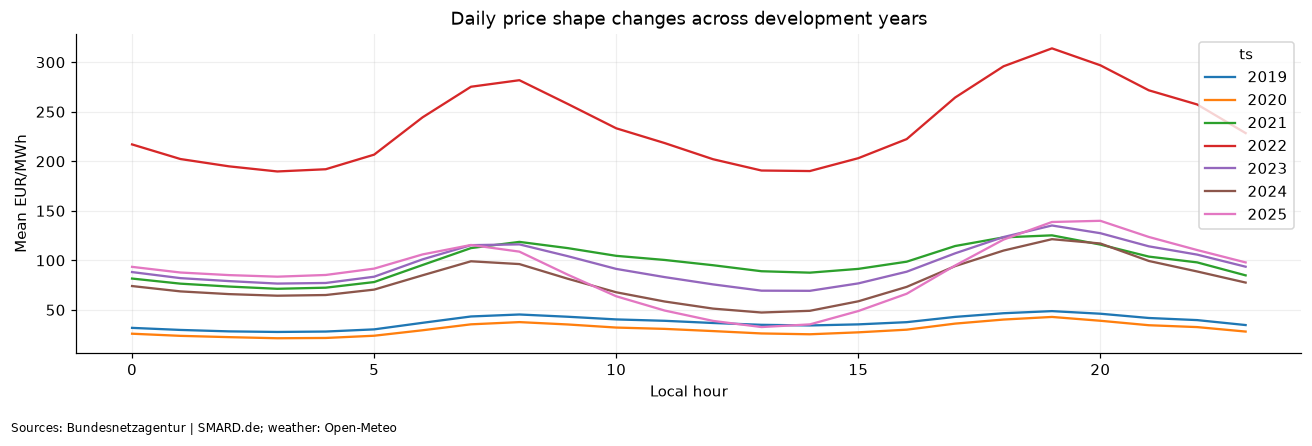

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for key, ax, title in [(eda_local.index.hour, axes[0], 'Local hour'),
                       (eda_local.index.dayofweek, axes[1], 'Weekday (0=Monday)'),
                       (eda_local.index.month, axes[2], 'Month')]:
    grouped = eda_local.groupby(key)[TARGET].agg(['mean', 'median'])
    grouped.plot(ax=ax, marker='o', title=title)
    ax.set_ylabel('EUR/MWh')
finish(fig, '03_calendar_patterns')
hour_year = eda_local.pivot_table(values=TARGET, index=eda_local.index.hour,
                                 columns=eda_local.index.year, aggfunc='mean')
fig, ax = plt.subplots(figsize=(12, 4))
hour_year.plot(ax=ax, title='Daily price shape changes across development years')
ax.set(xlabel='Local hour', ylabel='Mean EUR/MWh')
finish(fig, '04_hour_by_year')

,hours,mean,median,minimum,maximum,negative_hours,negative_pct,coverage_note
ts,,,,,,,,
2019,8759,37.67,38.06,-90.01,121.46,211,2.41,partial first local year
2020,8784,30.47,30.99,-83.94,200.04,298,3.39,full local year
2021,8760,96.85,75.48,-69.00,620.00,139,1.59,full local year
2022,8760,235.45,208.34,-19.04,871.00,69,0.79,full local year
2023,8760,95.18,98.02,-500.00,524.27,301,3.44,full local year
2024,8784,78.51,79.59,-135.45,936.28,457,5.20,full local year
2025,6407,87.67,94.17,-250.32,583.40,525,8.19,partial year before holdout


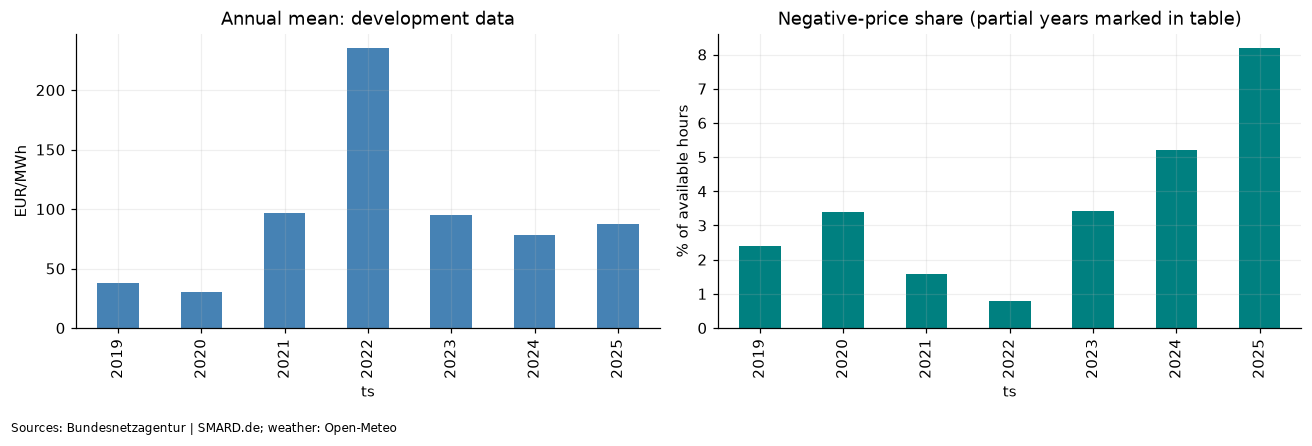

In [11]:
annual = eda_local.groupby(eda_local.index.year)[TARGET].agg(hours='size', mean='mean', median='median', minimum='min', maximum='max')
annual['negative_hours'] = eda_local[TARGET].lt(0).groupby(eda_local.index.year).sum()
annual['negative_pct'] = 100 * annual.negative_hours / annual.hours
annual['coverage_note'] = ['partial first local year' if y == 2019 else
                           'partial year before holdout' if y == 2025 else 'full local year'
                           for y in annual.index]
display(annual.round(2))
annual.to_csv(OUT / 'development_annual_prices.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
annual['mean'].plot.bar(ax=axes[0], color='steelblue', title='Annual mean: development data')
annual.negative_pct.plot.bar(ax=axes[1], color='teal', title='Negative-price share (partial years marked in table)')
axes[0].set_ylabel('EUR/MWh')
axes[1].set_ylabel('% of available hours')
finish(fig, '05_annual_regimes')

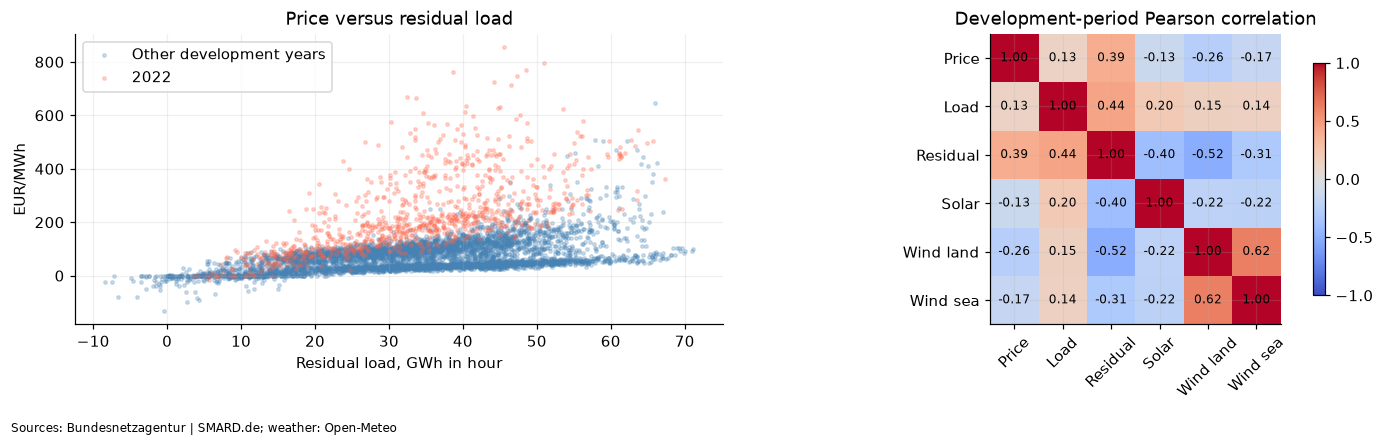

price_eur_mwh        1.000000
residual_load_mwh    0.393464
load_mwh             0.131249
solar_mwh           -0.132724
wind_offshore_mwh   -0.168069
wind_onshore_mwh    -0.261692
Name: correlation_with_price, dtype: float64

In [12]:
sample = eda.dropna().sample(min(6000, len(eda.dropna())), random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for is_crisis, label, color in [(False, 'Other development years', 'steelblue'), (True, '2022', 'tomato')]:
    part = sample.loc[(sample.index.tz_convert(TZ).year == 2022) == is_crisis]
    axes[0].scatter(part.residual_load_mwh / 1000, part[TARGET], s=5, alpha=.25, label=label, color=color)
axes[0].set(xlabel='Residual load, GWh in hour', ylabel='EUR/MWh', title='Price versus residual load')
axes[0].legend()
corr = eda.corr()
im = axes[1].imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
labels = ['Price', 'Load', 'Residual', 'Solar', 'Wind land', 'Wind sea']
axes[1].set(xticks=range(6), yticks=range(6), xticklabels=labels, yticklabels=labels,
            title='Development-period Pearson correlation')
axes[1].tick_params(axis='x', rotation=45)
for i in range(6):
    for j in range(6):
        axes[1].text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=axes[1], shrink=.8)
finish(fig, '06_market_relationships')
display(corr[TARGET].sort_values(ascending=False).rename('correlation_with_price'))

Weather can affect price through expected generation and demand. More sunlight often supports
more PV output; stronger wind often supports more wind generation; temperature affects demand.
These relationships are not exact conversion formulas: installed capacity, plant behaviour,
geography and time of year also matter. Residual load itself is mostly a derived column.

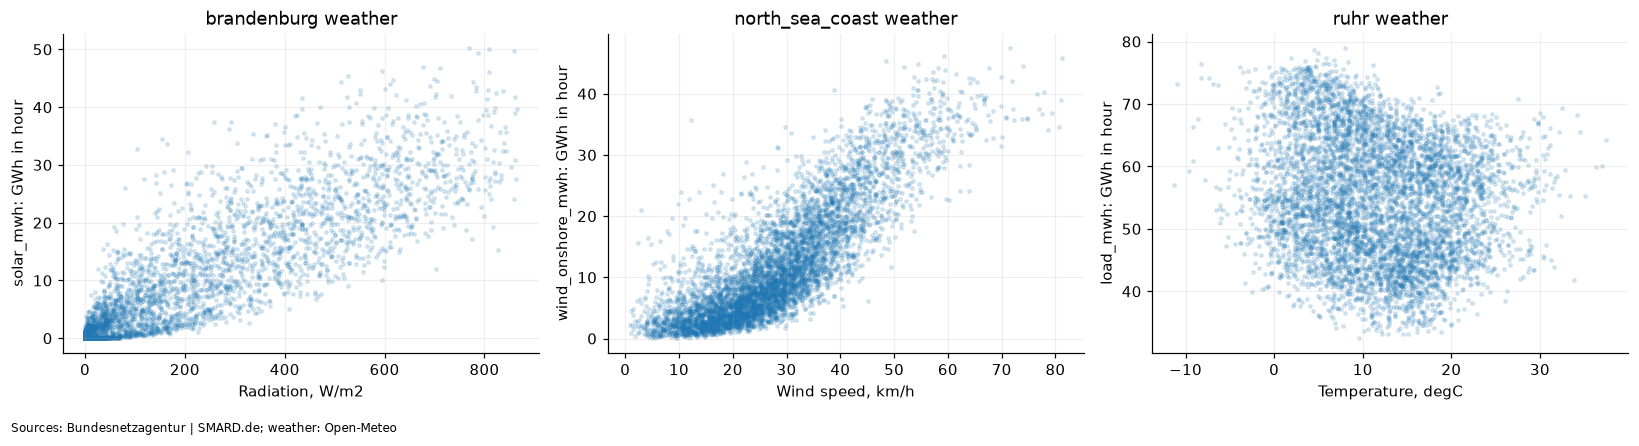

,price_eur_mwh,solar_mwh,wind_onshore_mwh,load_mwh
north_sea_coast__temperature_2m,-0.011,0.404,-0.228,-0.215
north_sea_coast__wind_speed_100m,-0.233,-0.183,0.832,0.134
north_sea_coast__shortwave_radiation,-0.107,0.858,-0.226,0.195
north_sea_coast__cloud_cover,-0.003,-0.117,0.164,0.099
brandenburg__temperature_2m,-0.034,0.459,-0.238,-0.183
brandenburg__wind_speed_100m,-0.220,-0.231,0.809,0.096
brandenburg__shortwave_radiation,-0.121,0.901,-0.217,0.215
brandenburg__cloud_cover,0.011,-0.096,0.159,0.133
ruhr__temperature_2m,-0.016,0.465,-0.228,-0.180
ruhr__wind_speed_100m,-0.234,-0.230,0.801,0.106


In [13]:
weather_eda = eda.join(archive, how='inner')
weather_sample = weather_eda.dropna().sample(min(6000, len(weather_eda.dropna())), random_state=SEED)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [('brandenburg__shortwave_radiation', 'solar_mwh', 'Radiation, W/m2'),
         ('north_sea_coast__wind_speed_100m', 'wind_onshore_mwh', 'Wind speed, km/h'),
         ('ruhr__temperature_2m', 'load_mwh', 'Temperature, degC')]
for ax, (x, y, label) in zip(axes, pairs):
    ax.scatter(weather_sample[x], weather_sample[y] / 1000, s=5, alpha=.15)
    ax.set(xlabel=label, ylabel=f'{y}: GWh in hour', title=f'{x.split("__")[0]} weather')
finish(fig, '07_weather_relationships')
weather_correlations = weather_eda.corr().loc[archive.columns, [TARGET, 'solar_mwh', 'wind_onshore_mwh', 'load_mwh']]
display(weather_correlations.round(3))
weather_correlations.to_csv(OUT / 'development_weather_correlations.csv')

## 5. Forecast provenance and availability

Open-Meteo is free for non-commercial use within published rate limits; local LightGBM
training incurs no API/model fee. Commercial API access requires the appropriate paid plan.
[Pricing](https://open-meteo.com/en/pricing).

The downloader now uses ECMWF IFS 0.25-degree forecasts from the **Previous Runs API**, with
`*_previous_day2` fields (48-hour lead), rather than the stitched historical endpoint.
This deliberately uses older forecasts. Exact publication times are not supplied, so the
availability claim assumes publication lag is shorter than the buffer printed below. It
is not a reconstruction of the most recent D-1 forecast run. [API semantics](https://open-meteo.com/en/docs/previous-runs-api).

Coverage begins in April 2024 in this experiment. Do not fabricate forecast history by filling
earlier dates with archive weather. Radiation is kept as a preceding-hour weather predictor.

In [3]:
local_days = forecast.index.tz_convert(TZ).normalize()
issue_local = (local_days.tz_localize(None) - pd.Timedelta(days=1) + pd.Timedelta(hours=11)).tz_localize(TZ)
nominal_forecast_time = forecast.index - pd.Timedelta(hours=forecast_meta['lead_hours'])
buffer_hours = (issue_local.tz_convert('UTC') - nominal_forecast_time).total_seconds() / 3600
print('Minimum nominal forecast-age buffer before 11:00 D-1:', buffer_hours.min(), 'hours')
assert buffer_hours.min() > 0
display(pd.DataFrame({'valid_time_utc': forecast.index[:3],
                      'nominal_forecast_time_utc': nominal_forecast_time[:3],
                      'prediction_issue_local': issue_local[:3]}))
print('Missing forecast cells:', int(forecast.isna().sum().sum()))

Minimum nominal forecast-age buffer before 11:00 D-1: 11.0 hours


,valid_time_utc,nominal_forecast_time_utc,prediction_issue_local
0,2024-04-01 00:00:00+00:00,2024-03-30 00:00:00+00:00,2024-03-31 11:00:00+02:00
1,2024-04-01 01:00:00+00:00,2024-03-30 01:00:00+00:00,2024-03-31 11:00:00+02:00
2,2024-04-01 02:00:00+00:00,2024-03-30 02:00:00+00:00,2024-03-31 11:00:00+02:00


Missing forecast cells: 645


## 6. Build features and freeze a fair comparison

`build_features` creates 9 calendar predictors, 24 lagged market predictors and 3 rolling
price statistics: 36 inputs, or 56 with forecast weather. Lags are 48, 72, 168 and 336 elapsed
hours. They can differ from the same local clock hour across DST. All rolling statistics
end 48 hours before delivery. The first 14 days are unavailable because of lag warm-up.

The returned table also contains the target. The backtester excludes it from X.
Both learned models use the **same eligible training timestamps**, starting when forecast
coverage exists. This isolates the effect of adding weather more fairly. Weekly retraining
uses calendar days; each fit uses only earlier delivery days, up to a two-year window.
Earlier test-day outcomes may enter later weekly fits once known: this is rolling evaluation.

Forecast cloud cover has source gaps. LightGBM handles these NaNs natively; we retain
them without filling from observations or future data. All other weather fields and
market predictors must be present. The backtest's explicit missing-feature option is
enabled only for LightGBM.

Baselines require only their price lag. All four methods must predict every expected test
hour; a missing prediction causes a clear failure rather than a silently smaller test set.

In [15]:
X_market = build_features(market)
X_weather = build_features(market, weather_forecast=forecast)
assert len(X_market.columns) - 1 == 36
assert len(X_weather.columns) - 1 == 56
required = list(X_market.columns) + [c for c in forecast if not c.endswith('cloud_cover')]
eligible = X_weather.dropna(subset=required).index
learn_market = X_market.loc[eligible]
learn_weather = X_weather.loc[eligible]
print('Eligible learned-model data:', eligible.min(), 'to', eligible.max(), '| rows:', len(eligible))
missing_test = expected_test.difference(eligible)
assert len(missing_test) == 0, f'Missing eligible test hours: {list(missing_test[:10])}'
assert market.loc[expected_test, TARGET].notna().all()

split_info = pd.DataFrame([
    {'role': 'Initial training (fixed parameters; no tuning)', 'start': eligible.min(),
     'end': eligible[eligible < TEST_BEGIN].max(), 'hours': int((eligible < TEST_BEGIN).sum())},
    {'role': 'Rolling retrospective test', 'start': TEST_BEGIN,
     'end': expected_test[-1], 'hours': len(expected_test)},
])
display(split_info)
print('Latest raw generation may be absent while older lagged features remain available.')

Eligible learned-model data: 2024-04-01 00:00:00+00:00 to 2026-09-25 23:00:00+00:00 | rows: 21792


,role,start,end,hours
0,Initial training (fixed parameters; no tuning),2024-04-01 00:00:00+00:00,2025-09-24 21:00:00+00:00,13006
1,Rolling retrospective test,2025-09-24 22:00:00+00:00,2026-09-24 21:00:00+00:00,8760


Latest raw generation may be absent while older lagged features remain available.


## 7. First baseline results

**Weekly seasonal naive:** predict the price from 168 hours earlier.
**Two-day naive:** predict the price from 48 hours earlier.

MAE is the average absolute error in EUR/MWh. RMSE gives more weight to large errors.
Neither uses a percentage denominator, so zero and negative prices are valid.
The results are measurements from this run, not expected performance targets.

In [16]:
class Lag48Baseline:
    def fit(self, X, y):
        return self
    def predict(self, X):
        return X[f'{TARGET}_lag48h'].to_numpy()

results = {}
def evaluate(name, data, factory, allow_missing_features=False):
    started = time.perf_counter()
    result = rolling_backtest(data, factory, TEST_START, TEST_END,
                              train_window_days=730, retrain_every_days=7,
                              allow_missing_features=allow_missing_features)
    pd.testing.assert_index_equal(result.predictions.index.as_unit('ns'), expected_test.as_unit('ns'), check_names=False)
    assert np.isfinite(result.predictions.to_numpy()).all(), f'Non-finite predictions from {name}'
    results[name] = result
    print(name, result.metrics(), f'elapsed {time.perf_counter()-started:.1f}s')
    return result

evaluate('Seasonal naive (168h)', X_market[[TARGET, f'{TARGET}_lag168h']], SeasonalNaive)
evaluate('Two-day naive (48h)', X_market[[TARGET, f'{TARGET}_lag48h']], Lag48Baseline)
baseline_results = pd.DataFrame({name: result.metrics() for name, result in results.items()}).T
display(baseline_results.round(3))
baseline_results.to_csv(OUT / 'baseline_results.csv', index_label='model')

Seasonal naive (168h) {'MAE': 36.73968721461188, 'RMSE': 56.568971189498896, 'n_hours': 8760} elapsed 2.3s


Two-day naive (48h) {'MAE': 37.866756849315074, 'RMSE': 58.1701532140231, 'n_hours': 8760} elapsed 2.1s


,MAE,RMSE,n_hours
Seasonal naive (168h),36.740,56.569,8760.0
Two-day naive (48h),37.867,58.170,8760.0


## 8. Enhanced models: LightGBM without and with weather

LightGBM combines decision trees to learn nonlinear relationships between the available
inputs and price. These fixed initial parameters have not been tuned on the test period.
Absolute-error training aligns with MAE. Both models use identical dates and settings;
only the extra 20 forecast-weather inputs differ. Adding inputs is not a guarantee of
improvement: the measured results below decide that.

In [17]:
model_params = dict(n_estimators=250, learning_rate=.05, num_leaves=31,
                    min_child_samples=40, reg_lambda=1.0, objective='regression_l1',
                    random_state=SEED, n_jobs=2, verbosity=-1)
def make_lgbm():
    return LGBMRegressor(**model_params)

evaluate('LightGBM market', learn_market, make_lgbm, allow_missing_features=True)
evaluate('LightGBM market + forecast weather', learn_weather, make_lgbm, allow_missing_features=True)

LightGBM market {'MAE': 29.96198168031522, 'RMSE': 44.82662321759161, 'n_hours': 8760} elapsed 86.9s


LightGBM market + forecast weather {'MAE': 19.192585961299894, 'RMSE': 32.07089335656704, 'n_hours': 8760} elapsed 139.3s


BacktestResult(predictions=                           y_true      y_pred
ts                                           
2025-09-24 22:00:00+00:00   73.30   54.629004
2025-09-24 23:00:00+00:00   69.69   47.190342
2025-09-25 00:00:00+00:00   67.81   46.970577
2025-09-25 01:00:00+00:00   68.09   46.119783
2025-09-25 02:00:00+00:00   71.69   54.928983
...                           ...         ...
2026-09-24 17:00:00+00:00  267.32  180.792429
2026-09-24 18:00:00+00:00  260.00  193.715813
2026-09-24 19:00:00+00:00  225.82  205.734224
2026-09-24 20:00:00+00:00  204.87  206.428082
2026-09-24 21:00:00+00:00  188.01  200.881308

[8760 rows x 2 columns])

,MAE,RMSE,n_hours,MAE_improvement_vs_weekly_pct
Seasonal naive (168h),36.740,56.569,8760,0.000
Two-day naive (48h),37.867,58.170,8760,-3.068
LightGBM market,29.962,44.827,8760,18.448
LightGBM market + forecast weather,19.193,32.071,8760,47.761


Adding forecast weather changes MAE by **+35.94% improvement** relative to the market-only model (negative means worse). All methods score the same **8,760 hours**.

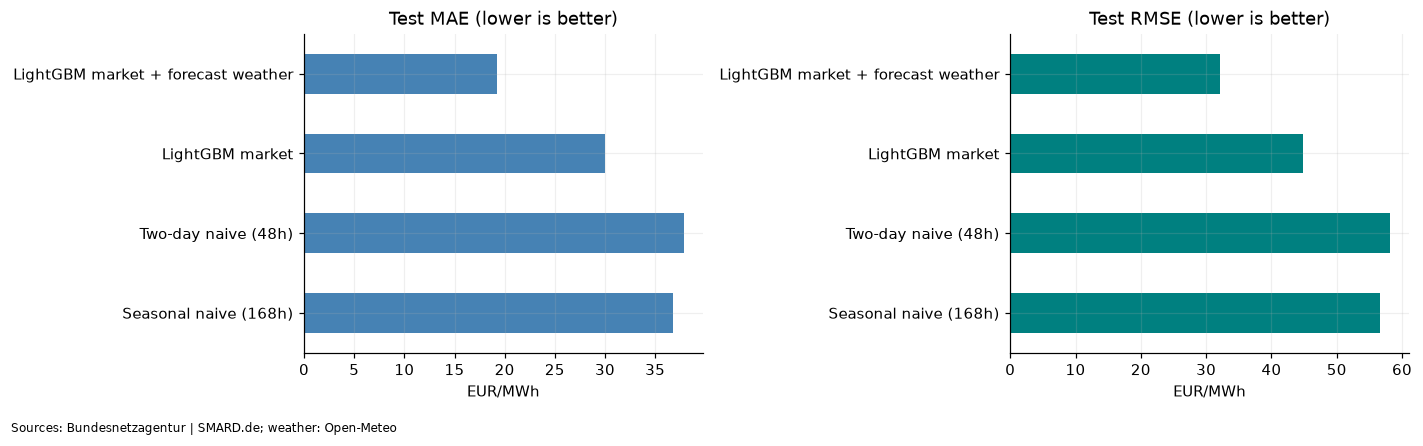

In [18]:
scores = pd.DataFrame({name: result.metrics() for name, result in results.items()}).T
scores['n_hours'] = scores.n_hours.astype(int)
scores['MAE_improvement_vs_weekly_pct'] = 100 * (1 - scores.MAE / scores.loc['Seasonal naive (168h)', 'MAE'])
display(scores.round(3))
scores.to_csv(OUT / 'model_results.csv', index_label='model')
predictions = pd.DataFrame({'actual': market.loc[expected_test, TARGET]}, index=expected_test)
for name, result in results.items():
    predictions[name] = result.predictions.y_pred
predictions.to_parquet(OUT / 'test_predictions.parquet')
predictions.to_csv(OUT / 'test_predictions.csv', index_label='timestamp_utc')
weather_gain = 100 * (1 - scores.loc['LightGBM market + forecast weather', 'MAE'] / scores.loc['LightGBM market', 'MAE'])
display(Markdown(f'Adding forecast weather changes MAE by **{weather_gain:+.2f}% improvement** relative to the market-only model (negative means worse). All methods score the same **{len(expected_test):,} hours**.'))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
scores.MAE.plot.barh(ax=axes[0], color='steelblue', title='Test MAE (lower is better)')
scores.RMSE.plot.barh(ax=axes[1], color='teal', title='Test RMSE (lower is better)')
for ax in axes:
    ax.set_xlabel('EUR/MWh')
finish(fig, '08_model_comparison')

## 9. Where do the errors occur?

Report error by hour, weekend and negative-price regime. These slices diagnose failure;
they are not permission to tune on the holdout. The example week is fixed to the first
seven test days rather than selected for a favourable visual result.

,Seasonal naive (168h),Two-day naive (48h),LightGBM market,LightGBM market + forecast weather
weekday,37.94,37.69,31.19,20.41
weekend,33.73,38.31,26.88,16.15


,Seasonal naive (168h),Two-day naive (48h),LightGBM market,LightGBM market + forecast weather
negative price,55.05,66.47,44.86,25.63
nonnegative price,35.62,36.12,29.05,18.80


Regime hour counts: {'nonnegative price': 8257, 'negative price': 503}


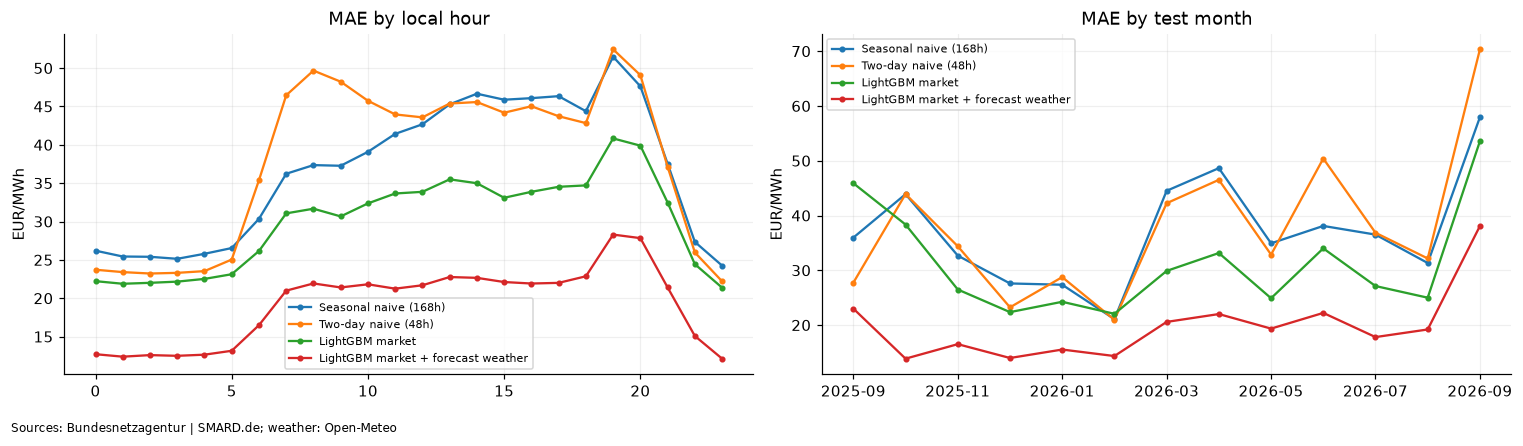

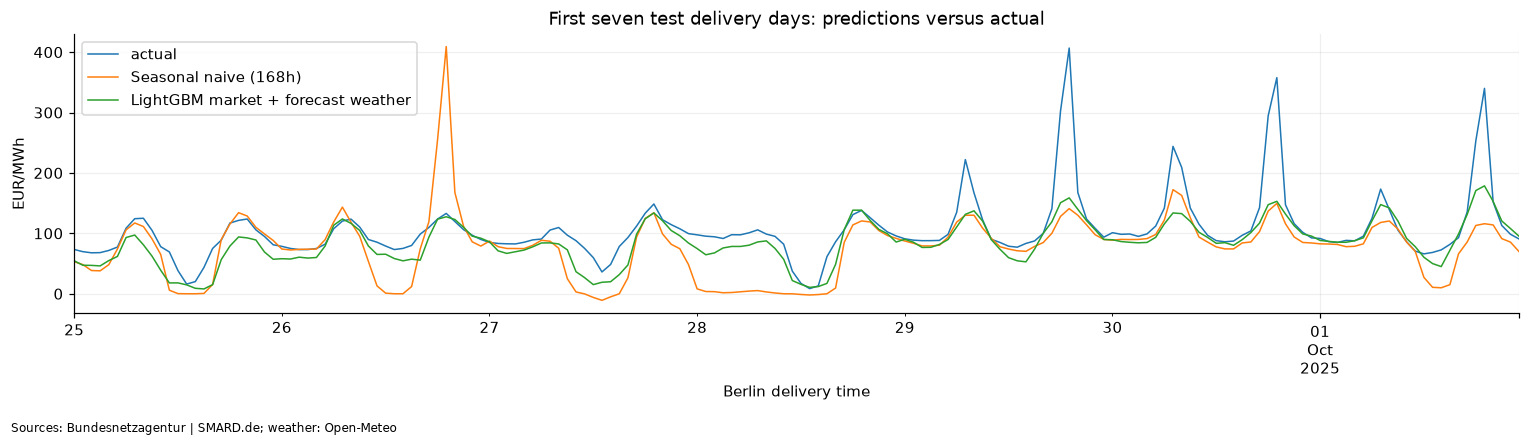

In [19]:
errors = predictions.drop(columns='actual').sub(predictions.actual, axis=0).abs()
test_local = predictions.index.tz_convert(TZ)
hourly_mae = errors.groupby(test_local.hour).mean()
weekend_mae = errors.groupby(np.where(test_local.dayofweek >= 5, 'weekend', 'weekday')).mean()
regime_mae = errors.groupby(np.where(predictions.actual < 0, 'negative price', 'nonnegative price')).mean()
monthly_mae = errors.groupby(test_local.strftime('%Y-%m')).mean()
display(weekend_mae.round(2))
display(regime_mae.round(2))
print('Regime hour counts:', pd.Series(np.where(predictions.actual < 0, 'negative price', 'nonnegative price')).value_counts().to_dict())
hourly_mae.to_csv(OUT / 'mae_by_local_hour.csv')
weekend_mae.to_csv(OUT / 'mae_by_weekend.csv')
regime_mae.to_csv(OUT / 'mae_by_price_regime.csv')
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hourly_mae.plot(ax=axes[0], marker='.', title='MAE by local hour')
monthly_mae.plot(ax=axes[1], marker='.', title='MAE by test month')
for ax in axes:
    ax.set_ylabel('EUR/MWh')
    ax.legend(fontsize=7)
finish(fig, '09_error_slices')

week_stop = (pd.Timestamp(TEST_START, tz=TZ) + pd.DateOffset(days=7)).tz_convert('UTC')
example_week = predictions.loc[predictions.index < week_stop].tz_convert(TZ)
fig, ax = plt.subplots(figsize=(14, 4))
example_week[['actual', 'Seasonal naive (168h)', 'LightGBM market + forecast weather']].plot(ax=ax, linewidth=1)
ax.set(title='First seven test delivery days: predictions versus actual', ylabel='EUR/MWh', xlabel='Berlin delivery time')
finish(fig, '10_forecast_week')

### Measured findings from this execution

- The weekly baseline has MAE **36.74 EUR/MWh**; market-only LightGBM achieves **29.96**;
  LightGBM with forecast weather achieves **19.19**, with RMSE **32.07 EUR/MWh**.
- Forecast weather reduces MAE by **35.9%** relative to market-only LightGBM,
  and the weather model improves on the weekly baseline by **47.8%**.
  All four methods cover **8,760 identical test hours**, September 25, 2025 through September 24, 2026.
- Development-period plots show higher prices during 2022, different hourly price shapes across years,
  and a positive association between residual load and price. These are descriptive associations,
  not causal estimates or a guarantee of a stable relationship in future years.
- Missing cloud cover affects 129 forecast hours per location; LightGBM retains those rows and uses
  native missing-value handling. No archive weather or future values were used to fill the gaps.
- These are initial retrospective results with fixed parameters. Exact forecast publication times
  and historical market revisions are not reconstructed. The conservative availability assumption
  remains material to interpretation; a new live evaluation is required before claiming live performance.


## 10. Interpretation, limits and next experiments

- This is an hourly point-forecast experiment. An enhanced model is not automatically a
  profitable trading strategy, a calibrated interval model, or a production service.
- Archive weather was used only for EDA. Forecast weather uses 48-hour lead semantics with
  an explicit publication-delay assumption, not exact historical availability timestamps.
- Market data is a downloaded revision snapshot. Exact historical revisions were not reconstructed.
- A two-year training window in this test mostly excludes 2022; claiming that this model
  learned the crisis would be misleading. Test a longer window using development data first.
- A 168-hour baseline preserves elapsed UTC hours, not necessarily local clock time at DST.
- Five weather coordinates are coarse proxies. More sites or generation-weighted weather
  could help, but only an independent evaluation can establish improvement.
- Do not invent an oracle gain or promise a weather-model improvement. All numbers above
  come from the same evaluated timestamps. No neural network or model tuning was run.

Next: add time-ordered tuning on a development period, investigate source revision flags,
evaluate explicit run-time weather selection if exact availability is required, then add
quantile models and test interval calibration. Freeze model choices before a new live trial.

Sources: [SMARD](https://www.smard.de), [Open-Meteo archive definitions](https://open-meteo.com/en/docs/historical-weather-api),
[Previous Runs](https://open-meteo.com/en/docs/previous-runs-api), [pricing](https://open-meteo.com/en/pricing).

In [20]:
run_metadata = {
    'created_at_utc': pd.Timestamp.now(tz='UTC').isoformat(), 'inputs': manifest,
    'test_start_local': TEST_START, 'test_end_local': TEST_END, 'timezone': TZ,
    'expected_test_hours': len(expected_test), 'model_params': model_params,
    'train_window_days': 730, 'retrain_every_days': 7,
    'weather_metadata': forecast_meta,
    'versions': {p: importlib.metadata.version(p) for p in ['pandas', 'numpy', 'lightgbm', 'scikit-learn']},
    'quality_policy': 'Raw files unchanged; negative prices kept; no imputation; strict full test-hour coverage.',
}
(OUT / 'run_metadata.json').write_text(json.dumps(run_metadata, indent=2), encoding='utf-8')
print('Saved results, audit tables, predictions and 10 figures to:', OUT)
display(pd.DataFrame({'artifact': sorted(p.name for p in OUT.iterdir() if p.is_file())}))

Saved results, audit tables, predictions and 10 figures to: C:\Users\rosha\OneDrive\Documents\de-power-price-forecast\data\processed\eda


,artifact
0,01_price_history.png
1,02_price_distribution.png
2,03_calendar_patterns.png
3,04_hour_by_year.png
4,05_annual_regimes.png
5,06_market_relationships.png
6,07_weather_relationships.png
7,08_model_comparison.png
8,09_error_slices.png
9,10_forecast_week.png
